In [85]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt

# Import the linear regression module from the scikit learn library.
from sklearn.linear_model import LinearRegression

In [86]:
# Resetando gerador de sequências pseudo-aleatórias de forma que os resultados apresentados sejam sempre os mesmos.
seed = 1234
np.random.seed(seed)

In [87]:
M = 1000

#atributos
x = np.random.uniform(-5,5,M)

#ruído
w = np.random.normal(0,np.sqrt(10),M)  #Distribuição aleatória gaussiana -> atributos: (media,np.sqrt(variancia),num de elementos)

#target function
y = 3+1.5*x+2.3*x**2

# observable function

y_noisy = y + w


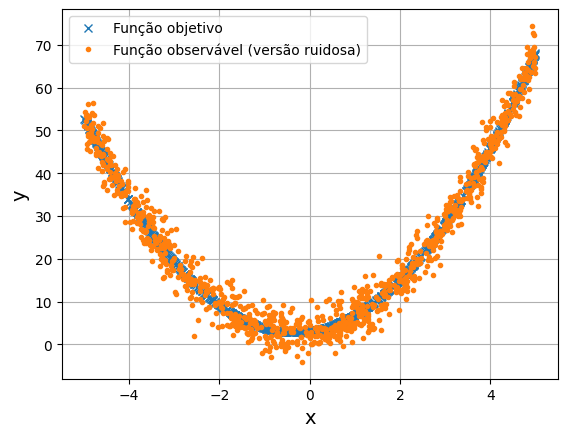

In [88]:
# Comparando a função observável com a objetivo.
fig = plt.figure()
plt.plot(x, y, 'x' , label='Função objetivo')
plt.plot(x, y_noisy, '.', label='Função observável (versão ruidosa)')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [89]:
# np.c_ concatenates vectors.
X = np.c_[np.ones((M, 1)), x, x**2] # Precisa colocar todas as ordens da equação, o exemplo tem x e x²

# Solve by applying the least-Squares method.
# We use the inv() function from NumPy’s Linear Algebra module (np.linalg) to compute the inverse of a matrix.
# We use dot() method for matrix multiplication.
a_numpy = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)

# Print best solution.
print('a0: %1.4f' % (a_numpy[0]))
print('a1: %1.4f' % (a_numpy[1]))
print('a2: %1.4f' % (a_numpy[2]))


a0: 2.9844
a1: 1.4885
a2: 2.3073


In [90]:
# Performing predictions with the hypothesis function.
yhat_numpy = X.dot(a_numpy)

# Calculating the Mean Squared Error (MSE).
Je_optimum = (1.0/M)*np.sum(np.power((y_noisy - yhat_numpy), 2))

# Print the MSE.
print('MSE: %1.6f' % Je_optimum)


# Se o erro estiver próximo da variância então está correto.

MSE: 9.937470


#Encontrando a solução ótima com a equação normal implementada pela biblioteca Scikit-learn

In [91]:
# Usando o poly, pois é um polinômio, tem x e x².
X_poly = np.c_[x,x**2]

# Instantiate the LinearRegression class.
reg = LinearRegression()

# Train the model.
reg.fit(X_poly, y_noisy)

print('a0: %1.4f' % (reg.intercept_)) # Intercept = a0
print('a1: %1.4f' % (reg.coef_[0]))   # Coef. de x
print('a2: %1.4f' % (reg.coef_[1]))   # Coef. de x²

# Performing predictions with the hypothesis function.
yhat_sklearn = reg.predict(X_poly)

# Calculating the Mean Squared Error (MSE).
Je_sklearn = (1.0/M)*np.sum(np.power((y_noisy - yhat_sklearn), 2))

# Print the MSE.
print('MSE: %1.6f' % Je_sklearn)

a0: 2.9844
a1: 1.4885
a2: 2.3073
MSE: 9.937470


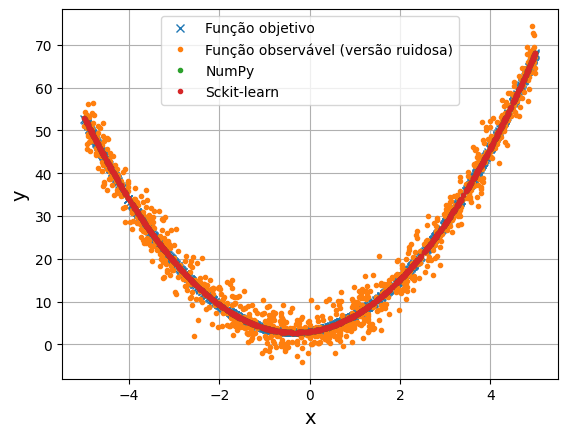

In [92]:
# Plot pair example/label.
fig = plt.figure()
plt.plot(x, y, 'x', label='Função objetivo', linewidth=7)
plt.plot(x, y_noisy, '.', label='Função observável (versão ruidosa)')
plt.plot(x, yhat_numpy, '.', label='NumPy', linewidth=4)
plt.plot(x, yhat_sklearn, '.', label='Sckit-learn')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
plt.show()

#BATELADA

Gradiente Descendente (a0, a1, a2): [1.81527418 1.50368893 2.37695403]
Erro quadrático médio (gradiente): 0.6186933727972238


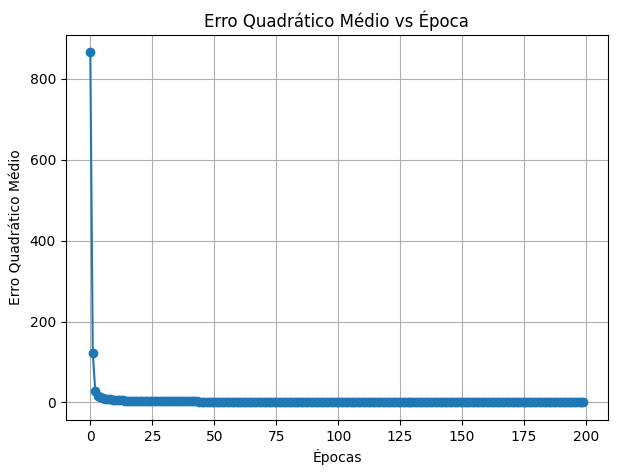

In [97]:
a_vet = np.zeros((3, 1)) # Vetor de pesos inicializados como 0, shape (3,1) pois temos a0,a1,e a2
alpha = 0.01  # passo de aprendizagem
n_epochs = 200
errors = [] # lista para guardar o erro quadrático médio ao longo das iterações.


# modelo atualizado repetidamente por 200 épocas
for epoch in range(n_epochs):
    # Matriz colinas [1,x,x²]
    # @ produto matricial entre x e os pesos a_vet
    # y_pred: vetor com as predições.
    y_pred = X @ a_vet

    # garante que y esteja na forma de vetor coluna.
    y = y.reshape(-1, 1)

    # diferença entre a predição e o valor real.
    error = y_pred - y

    # GRADIENTE
    grad = (1/M) * (X.T @ error)

    # Atualiza os coeficientes na direção contrária ao gradiente para minimizar o erro.
    a_vet -= alpha * grad

    # Erro quadrático médio
    mse = np.mean(error**2)
    errors.append(mse)

print("Gradiente Descendente (a0, a1, a2):", a_vet.ravel())
print("Erro quadrático médio (gradiente):", errors[-1])

### --- Plot do erro por iteração ---
plt.figure(figsize=(7, 5))
plt.plot(range(n_epochs), errors, marker='o')
plt.title("Erro Quadrático Médio vs Época")
plt.xlabel("Épocas")
plt.ylabel("Erro Quadrático Médio")
plt.grid(True)
plt.show()